# Inspect a generated scene

Phase 1 sanity-checking: build one T-joint, look at the numbers, plot the cloud and the
three D19 seam curves.

Run from the repo root (`weld_generator/`).

In [1]:
import sys, numpy as np
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/

from weldgen.config import load_config
from weldgen.scene import generate_scene

SEED_NUMBER = 1500

cfg = load_config("../configs/playground.yaml")
scene, arrays = generate_scene(cfg, seed=SEED_NUMBER)

print("scene_id ", scene["scene_id"])
print("twin_key ", scene["twin_key"])
print("quality  ", scene["joint"]["quality_level"])
print("included ", round(scene["joint"]["included_angle_deg"], 3), "deg")
print("root gap ", round(scene["fit"]["root_gap_mm"], 3), "mm")
print("points   ", scene["cloud"]["n_points"])

scene_id  a962acb4-0000001500
twin_key  2bd71feb9d749f13
quality   B
included  0.0 deg
root gap  0.159 mm
points    18096


## Seams

A T-joint has two fillets (D5). `included_angle_deg` is one number for the scene, but the
two seams carry *different* dihedrals summing to 180 — that is D18's point that the two
quantities are not interchangeable.

In [2]:
for s in scene["seams"]:
    print(f'seam {s["id"]}  {s["face_pair"]}  len={s["length_mm"]:8.3f} mm  '
          f'dihedral={s["dihedral_deg"]:6.2f}  weldable={s["weldable"]}')

seam 0  ['A:+u', 'B:-w']  len=  36.458 mm  dihedral= 90.00  weldable=True
seam 1  ['A:+v', 'B:-w']  len= 305.925 mm  dihedral= 90.00  weldable=True
seam 2  ['A:+w', 'B:+u']  len=  36.458 mm  dihedral= 90.00  weldable=True
seam 3  ['A:+w', 'B:-u']  len=  36.458 mm  dihedral= 90.00  weldable=True
seam 4  ['A:+w', 'B:-v']  len= 305.925 mm  dihedral= 90.00  weldable=True
seam 5  ['A:-u', 'B:-w']  len=  36.458 mm  dihedral= 90.00  weldable=True


## D19: the three seam definitions

The stored curve is `nominal`. `root` and `gap_mid` ship as derived arrays so the
conversion is a subtraction, not a re-derivation. At a right angle the offsets are
`0`, `g/2`, `g` — but that closed form does not survive a sampled included angle.

In [3]:
g = scene["fit"]["root_gap_mm"]
for s in scene["seams"]:
    i = s["id"]
    nom = arrays[f"seams.npz:seam_{i}"]
    root = arrays[f"seams.npz:seam_{i}_root"]
    mid  = arrays[f"seams.npz:seam_{i}_gapmid"]
    print(f'seam {i}:  |root-nom| = {np.linalg.norm(root[0]-nom[0]):.4f}   '
          f'|mid-nom| = {np.linalg.norm(mid[0]-nom[0]):.4f}   (g = {g:.4f})')

seam 0:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)
seam 1:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)
seam 2:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)
seam 3:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)
seam 4:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)
seam 5:  |root-nom| = 0.1586   |mid-nom| = 0.0793   (g = 0.1586)


## Plot

**The scene is placed at a sampled world pose** (random yaw + translation, deliberately —
SCHEMA.md §1.1, so nothing about the joint leaks from the world axes). So slicing on world
X and plotting world (y, z) is *not* a cross-section of anything: the markers land at
arbitrary spots and move with every seed.

`weldgen.viz.assembly_frame` undoes the pose. In that frame A's top face is `z = 0`, B
stands at `y >= 0` starting at `z = g`, and the seam runs along `+X` — so the cross-section
is the canonical drawing every time.

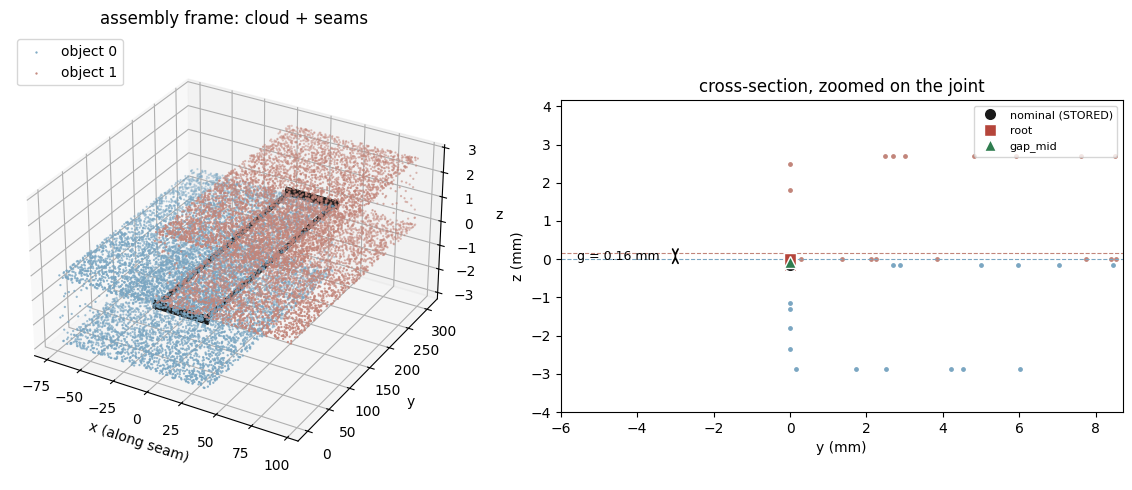

In [4]:
import matplotlib.pyplot as plt
from weldgen.viz import assembly_frame, cross_section, to_assembly

T = assembly_frame(scene)                      # world -> assembly
xyz = to_assembly(arrays["cloud.npz:xyz"], T)
oid = arrays["cloud.npz:object_id"]
g   = scene["fit"]["root_gap_mm"]
t_B = next(o for o in scene["objects"] if o["id"] == "B")["thickness_mm"]

fig = plt.figure(figsize=(12, 5))

# ---- 3D -------------------------------------------------------------------------
ax = fig.add_subplot(121, projection="3d")
for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
    m = oid == o
    ax.scatter(xyz[m, 0], xyz[m, 1], xyz[m, 2], s=0.4, c=c, label=f"object {o}")
for s in scene["seams"]:
    q = to_assembly(arrays[f'seams.npz:seam_{s["id"]}'], T)
    ax.plot(q[:, 0], q[:, 1], q[:, 2], lw=3.75, c="#1a1a1a")
ax.set_box_aspect([1, 1, 0.6]); ax.legend(loc="upper left")
ax.set_xlabel("x (along seam)"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("assembly frame: cloud + seams")

# ---- cross-section, zoomed on the joint ------------------------------------------
# The gap is ~1 mm against 200 mm plates, so it is invisible unless we zoom.
ax2 = fig.add_subplot(122)
band = cross_section(xyz, half_width_mm=3.0)
for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
    m = band & (oid == o)
    ax2.scatter(xyz[m, 1], xyz[m, 2], s=6, c=c)

styles = {"": ("o", "#1a1a1a", "nominal (STORED)"),
          "_root": ("s", "#b5453b", "root"),
          "_gapmid": ("^", "#2f7d4f", "gap_mid")}
for s in scene["seams"]:
    i = s["id"]
    for key, (mk, c, lab) in styles.items():
        q = to_assembly(arrays[f"seams.npz:seam_{i}{key}"], T)
        ax2.plot(q[0, 1], q[0, 2], mk, ms=9, c=c, mec="white", mew=1.0,
                 label=lab if i == 0 else None, zorder=5)

ax2.axhline(0.0, lw=0.8, ls="--", c="#7aa6c2")   # A top face
ax2.axhline(g,   lw=0.8, ls="--", c="#c2857a")   # B bottom face
ax2.annotate("", xy=(-3, 0), xytext=(-3, g), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax2.text(-3.4, g / 2, f"g = {g:.2f} mm", ha="right", va="center", fontsize=9)

pad = max(4.0 * g, 4.0)
ax2.set_xlim(-6, t_B + 6); ax2.set_ylim(-pad, pad + g)
ax2.set_aspect("equal"); ax2.set_xlabel("y (mm)"); ax2.set_ylabel("z (mm)")
ax2.legend(loc="upper right", fontsize=8); ax2.set_title("cross-section, zoomed on the joint")
plt.tight_layout()

### Reading the cross-section

The two fillets sit at `y = 0` and `y = t_B` — the two faces of the standing plate. At each:

* **nominal** (stored) on A's top face, `z = 0` — where the extended planes meet
* **gap_mid** at `z = g/2`, exactly midway between A's top face and B's bottom face
* **root** at `z = g`, B's bottom edge — the innermost corner of the joint

The spread between them is `O(g)`, which at the reference 1,1 mm gap is larger than the
~0,6 mm RMSE the literature reports. That is the whole reason D19 exists.

In [5]:
for s in scene["seams"]:
    i = s["id"]
    n = to_assembly(arrays[f"seams.npz:seam_{i}"], T)[0]
    r = to_assembly(arrays[f"seams.npz:seam_{i}_root"], T)[0]
    m = to_assembly(arrays[f"seams.npz:seam_{i}_gapmid"], T)[0]
    print(f'seam {i} {tuple(s["face_pair"])}  y = {n[1]:6.3f}')
    print(f'    nominal z = {n[2]:7.4f}   (expect 0)')
    print(f'    gap_mid z = {m[2]:7.4f}   (expect g/2 = {g/2:.4f})')
    print(f'    root    z = {r[2]:7.4f}   (expect g   = {g:.4f})')

seam 0 ('A:+u', 'B:-w')  y =  0.000
    nominal z = -0.0000   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.1586   (expect g   = 0.1586)
seam 1 ('A:+v', 'B:-w')  y =  0.000
    nominal z = -0.0000   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.1586   (expect g   = 0.1586)
seam 2 ('A:+w', 'B:+u')  y =  0.000
    nominal z = -0.1586   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.0000   (expect g   = 0.1586)
seam 3 ('A:+w', 'B:-u')  y = 305.925
    nominal z = -0.1586   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.0000   (expect g   = 0.1586)
seam 4 ('A:+w', 'B:-v')  y = 305.925
    nominal z = -0.1586   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.0000   (expect g   = 0.1586)
seam 5 ('A:-u', 'B:-w')  y = 305.925
    nominal z = -0.0000   (expect 0)
    gap_mid z = -0.0793   (expect g/2 = 0.0793)
    root    z = -0.1586   (expe

## Determinism

The Phase 1 gate (D15). The content hash is defined on *content*, not file bytes —
`np.savez` embeds zip timestamps, so byte-identity is unachievable.

In [6]:
from weldgen.hashing import content_hash

a = content_hash(*generate_scene(cfg, SEED_NUMBER))
b = content_hash(*generate_scene(cfg, SEED_NUMBER))
print(a)
print("repeatable:", a == b)

# provenance is excluded, so re-running next month still matches
sc, ar = generate_scene(cfg, SEED_NUMBER)
sc["provenance"]["created_utc"] = "1999-01-01T00:00:00Z"
print("provenance-independent:", content_hash(sc, ar) == a)

94c32ece15b3c6c6bfc18e34c86be950dabca56a234ebc7bef16a07a611493cf
repeatable: True
provenance-independent: True
